# Classifying Penguins with Keras Day 2

In [1]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

2026-05-14 13:04:30.331810: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
# drop Nan rows
penguins.dropna(inplace=True)

In [16]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: object


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [17]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]])

### Defining the model

In [28]:
#construct the model
tf.random.set_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [29]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107 (428.00 B)

 Trainable params: 107 (428.00 B)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [30]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=10, 
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 0.2830 - loss: 1.3933 - val_accuracy: 0.1852 - val_loss: 1.5017
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.2830 - loss: 1.3783 - val_accuracy: 0.1852 - val_loss: 1.4838
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.2783 - loss: 1.3637 - val_accuracy: 0.2037 - val_loss: 1.4663
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.2783 - loss: 1.3494 - val_accuracy: 0.2037 - val_loss: 1.4492
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.2877 - loss: 1.3355 - val_accuracy: 0.2222 - val_loss: 1.4325
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2877 - loss: 1.3221 - val_accuracy: 0.1852 - val_loss: 1.4164
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.2925 - loss: 1.3090 - val_accuracy: 0.1667 - val_loss: 1.4007
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.2972 - loss: 1.2963 - val_accuracy: 0.1481 - val_loss: 1

### Evaluating on the test data

In [31]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

 Test Set Evaluation:
Test Accuracy: 0.2537
Test Precision: 0.3164
Test Recall: 0.2537
Test F1 Score: 0.2684
Test ROC AUC Score: 0.3214


### Evaluating model training using loss and accuracy

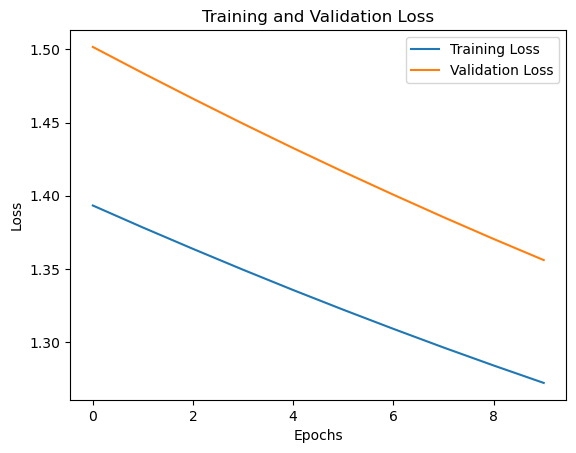

In [32]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

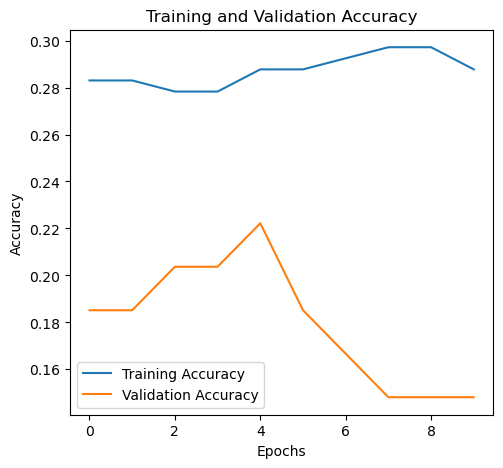

In [33]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

They are different (worse for me), probably because the weights keep changing.

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

It makes them more reproducible

Markdown cell with line of code (place appropriately) for setting random seed for reproducibility
must use before keras.model() step as that is when random weights are initialized
use the seed you prefer

tf.random.set_seed(42)

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

The expanding configuration appears to work best for this penguin classification task, likely because the middle expansion layer learns richer feature representations that are then compressed for the final classification layer. Test accuracy: 0.8358 Test Loss: 0.922. The curves saw steady improvement throughout training, validation accuracy reaches ~90.7%

Configuration 1: FUNNEL Architecture (64 → 32 → 16 → 3)
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 409ms/step - accuracy: 0.4434 - loss: 1.0447 - val_accuracy: 0.5556 - val_loss: 1.0073
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5472 - loss: 0.9993 - val_accuracy: 0.7407 - val_loss: 0.9623
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7264 - loss: 0.9560 - val_accuracy: 0.8519 - val_loss: 0.9184
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7736 - loss: 0.9146 - val_accuracy: 0.8889 - val_loss: 0.8759
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8113 - loss: 0.8746 - val_accuracy: 0.8889 - val_loss: 0.8353
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8160 - loss: 0.8359 - val_accuracy: 0.8704 - val_loss: 0.7961
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8160 - loss: 0.7984 - val_accuracy: 0.8519 - val_loss: 0.7574
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 

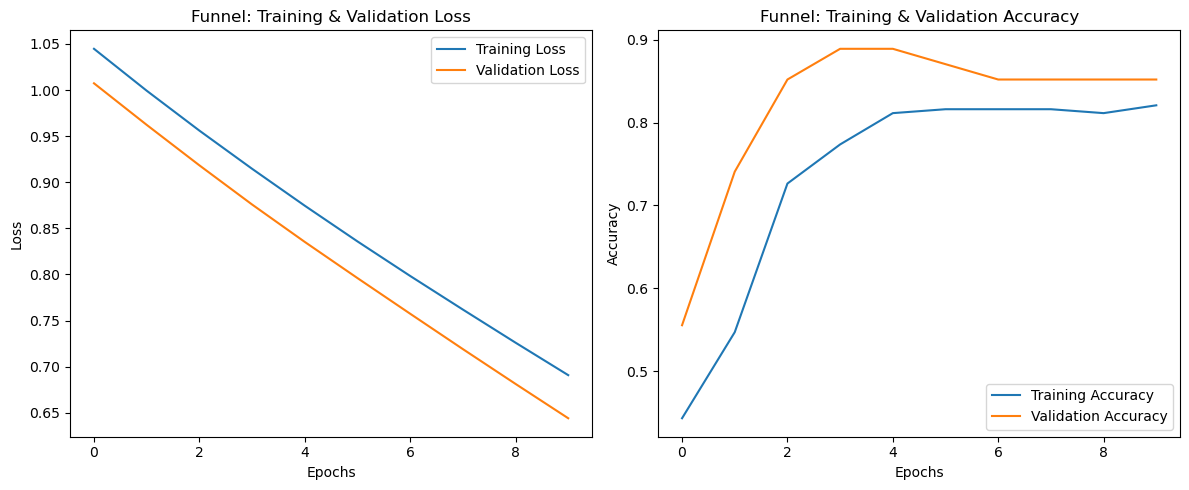

In [34]:
# Configuration 1: FUNNEL (decreasing neurons)
# Architecture: 64 → 32 → 16 → 3
print("=" * 60)
print("Configuration 1: FUNNEL Architecture (64 → 32 → 16 → 3)")
print("=" * 60)

tf.random.set_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model1 = keras.Model(inputs=inputs, outputs=outputs, name="funnel_model")

model1.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history1 = model1.fit(X_train_scaled, y_train, 
                      batch_size=128, 
                      epochs=10, 
                      validation_split=0.2, 
                      verbose=1)

y_pred_prob1 = model1.predict(X_test_scaled, verbose=0)
y_pred1 = np.argmax(y_pred_prob1, axis=1)
accuracy1 = accuracy_score(y_test, y_pred1)
test_loss1 = model1.evaluate(X_test_scaled, y_test, verbose=0)[0]

print(f"\nTest Accuracy: {accuracy1:.4f}")
print(f"Test Loss: {test_loss1:.4f}")
print(f"Final Training Accuracy: {history1.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history1.history['val_accuracy'][-1]:.4f}")

# Plot funnel curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Funnel: Training & Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Funnel: Training & Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Configuration 2: FLAT Architecture (24 → 24 → 24 → 3)
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.2547 - loss: 1.1407 - val_accuracy: 0.2593 - val_loss: 1.1106
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3396 - loss: 1.0998 - val_accuracy: 0.4259 - val_loss: 1.0760
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4623 - loss: 1.0620 - val_accuracy: 0.5926 - val_loss: 1.0429
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5708 - loss: 1.0261 - val_accuracy: 0.6481 - val_loss: 1.0112
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7028 - loss: 0.9915 - val_accuracy: 0.7222 - val_loss: 0.9792
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7642 - loss: 0.9579 - val_accuracy: 0.7778 - val_loss: 0.9473
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8255 - loss: 0.9256 - val_accuracy: 0.7963 - val_loss: 0.9170
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8443 - 

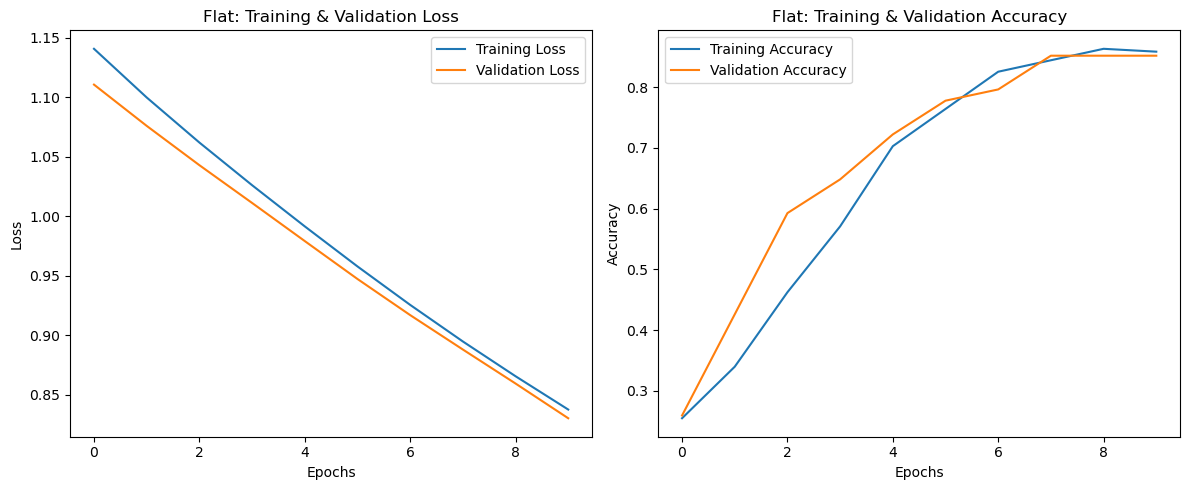

In [35]:
# Configuration 2: FLAT (constant neurons)
# Architecture: 24 → 24 → 24 → 3
print("=" * 60)
print("Configuration 2: FLAT Architecture (24 → 24 → 24 → 3)")
print("=" * 60)

tf.random.set_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(24, activation='relu')(inputs)
x = layers.Dense(24, activation='relu')(x)
x = layers.Dense(24, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model2 = keras.Model(inputs=inputs, outputs=outputs, name="flat_model")

model2.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history2 = model2.fit(X_train_scaled, y_train, 
                      batch_size=128, 
                      epochs=10, 
                      validation_split=0.2, 
                      verbose=1)

y_pred_prob2 = model2.predict(X_test_scaled, verbose=0)
y_pred2 = np.argmax(y_pred_prob2, axis=1)
accuracy2 = accuracy_score(y_test, y_pred2)
test_loss2 = model2.evaluate(X_test_scaled, y_test, verbose=0)[0]

print(f"\nTest Accuracy: {accuracy2:.4f}")
print(f"Test Loss: {test_loss2:.4f}")
print(f"Final Training Accuracy: {history2.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history2.history['val_accuracy'][-1]:.4f}")

# Plot flat curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Flat: Training & Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Flat: Training & Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Configuration 3: BOTTLENECK Architecture (12 → 48 → 12 → 3)
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 393ms/step - accuracy: 0.4057 - loss: 1.0792 - val_accuracy: 0.4074 - val_loss: 1.0292
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4575 - loss: 1.0619 - val_accuracy: 0.4630 - val_loss: 1.0161
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.5142 - loss: 1.0459 - val_accuracy: 0.5926 - val_loss: 1.0029
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5896 - loss: 1.0305 - val_accuracy: 0.5926 - val_loss: 0.9888
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5991 - loss: 1.0148 - val_accuracy: 0.6481 - val_loss: 0.9727
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.6274 - loss: 0.9983 - val_accuracy: 0.7407 - val_loss: 0.9547
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7123 - loss: 0.9810 - val_accuracy: 0.8704 - val_loss: 0.9355
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accurac

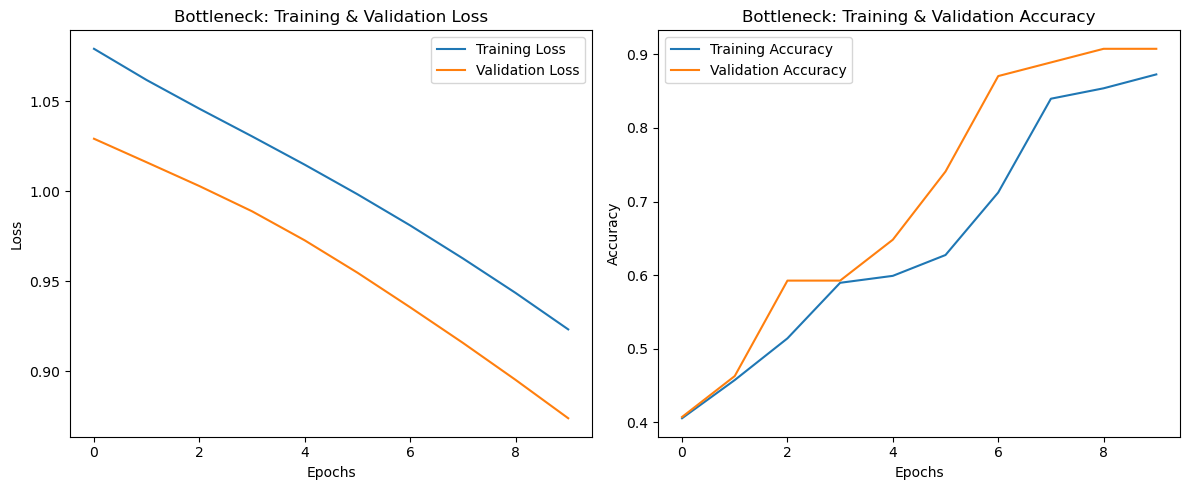

In [ ]:
# Configuration 3: BOTTLENECK 
# Architecture: 12 → 48 → 12 → 3
print("=" * 60)
print("Configuration 3: BOTTLENECK Architecture (12 → 48 → 12 → 3)")
print("=" * 60)

tf.random.set_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(12, activation='relu')(inputs)
x = layers.Dense(48, activation='relu')(x)
x = layers.Dense(12, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model3 = keras.Model(inputs=inputs, outputs=outputs, name="bottleneck_model")

model3.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history3 = model3.fit(X_train_scaled, y_train, 
                      batch_size=128, 
                      epochs=10, 
                      validation_split=0.2, 
                      verbose=1)

y_pred_prob3 = model3.predict(X_test_scaled, verbose=0)
y_pred3 = np.argmax(y_pred_prob3, axis=1)
accuracy3 = accuracy_score(y_test, y_pred3)
test_loss3 = model3.evaluate(X_test_scaled, y_test, verbose=0)[0]

print(f"\nTest Accuracy: {accuracy3:.4f}")
print(f"Test Loss: {test_loss3:.4f}")
print(f"Final Training Accuracy: {history3.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history3.history['val_accuracy'][-1]:.4f}")

# Plot bottleneck curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Bottleneck: Training & Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history3.history['accuracy'], label='Training Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Bottleneck: Training & Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

Validation accuracy improved rapidly from 5 to 10 epochs (reaching ~87%), then plateaued with no additional gains or performance degradation at 15+ epochs, indicating overfitting. The minimum number of epochs needed for reliable model performance was 10 epochs, achieving 82.09% test accuracy with stable, well-generalized validation curve

In [38]:
# Epoch Variation Experiment using Bottleneck Architecture
# Testing epochs: 5, 10, 15, 20, 30
epoch_configs = [5, 10, 15, 20, 30]
epoch_results = {
    'epochs': [],
    'test_accuracy': [],
    'test_loss': [],
    'final_train_acc': [],
    'final_val_acc': [],
    'histories': []
}

print("=" * 70)
print("EPOCH VARIATION EXPERIMENTS - Bottleneck Architecture (12→48→12)")
print("=" * 70)

for epochs in epoch_configs:
    print(f"\n{'─' * 70}")
    print(f"Training with {epochs} epochs...")
    print(f"{'─' * 70}")
    
    tf.random.set_seed(42)
    
    inputs = keras.Input(shape=(6,))
    x = layers.Dense(12, activation='relu')(inputs)
    x = layers.Dense(48, activation='relu')(x)
    x = layers.Dense(12, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=["accuracy"],
    )
    
    history = model.fit(X_train_scaled, y_train, 
                        batch_size=128, 
                        epochs=epochs, 
                        validation_split=0.2, 
                        verbose=0)
    
    y_pred_prob = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    test_acc = accuracy_score(y_test, y_pred)
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)[0]
    
    # Store results
    epoch_results['epochs'].append(epochs)
    epoch_results['test_accuracy'].append(test_acc)
    epoch_results['test_loss'].append(test_loss)
    epoch_results['final_train_acc'].append(history.history['accuracy'][-1])
    epoch_results['final_val_acc'].append(history.history['val_accuracy'][-1])
    epoch_results['histories'].append(history)
    
    print(f"Test Accuracy:        {test_acc:.4f}")
    print(f"Test Loss:            {test_loss:.4f}")
    print(f"Train Accuracy:       {history.history['accuracy'][-1]:.4f}")
    print(f"Validation Accuracy:  {history.history['val_accuracy'][-1]:.4f}")

EPOCH VARIATION EXPERIMENTS - Bottleneck Architecture (12→48→12)

──────────────────────────────────────────────────────────────────────
Training with 5 epochs...
──────────────────────────────────────────────────────────────────────
Test Accuracy:        0.5075
Test Loss:            0.9162
Train Accuracy:       0.4481
Validation Accuracy:  0.4815

──────────────────────────────────────────────────────────────────────
Training with 10 epochs...
──────────────────────────────────────────────────────────────────────
Test Accuracy:        0.8209
Test Loss:            0.9070
Train Accuracy:       0.7972
Validation Accuracy:  0.8704

──────────────────────────────────────────────────────────────────────
Training with 15 epochs...
──────────────────────────────────────────────────────────────────────
Test Accuracy:        0.5672
Test Loss:            0.8763
Train Accuracy:       0.6085
Validation Accuracy:  0.6852

──────────────────────────────────────────────────────────────────────
Traini


EPOCH COMPARISON SUMMARY

  Epochs  Test Accuracy  Test Loss  Final Train Acc  Final Val Acc
      5       0.507463   0.916244         0.448113       0.481481
     10       0.820896   0.907016         0.797170       0.870370
     15       0.567164   0.876350         0.608491       0.685185
     20       0.820896   0.621853         0.858491       0.888889
     30       0.791045   0.482291         0.783019       0.833333

BEST PERFORMANCE: 10 epochs
   Test Accuracy: 0.8209


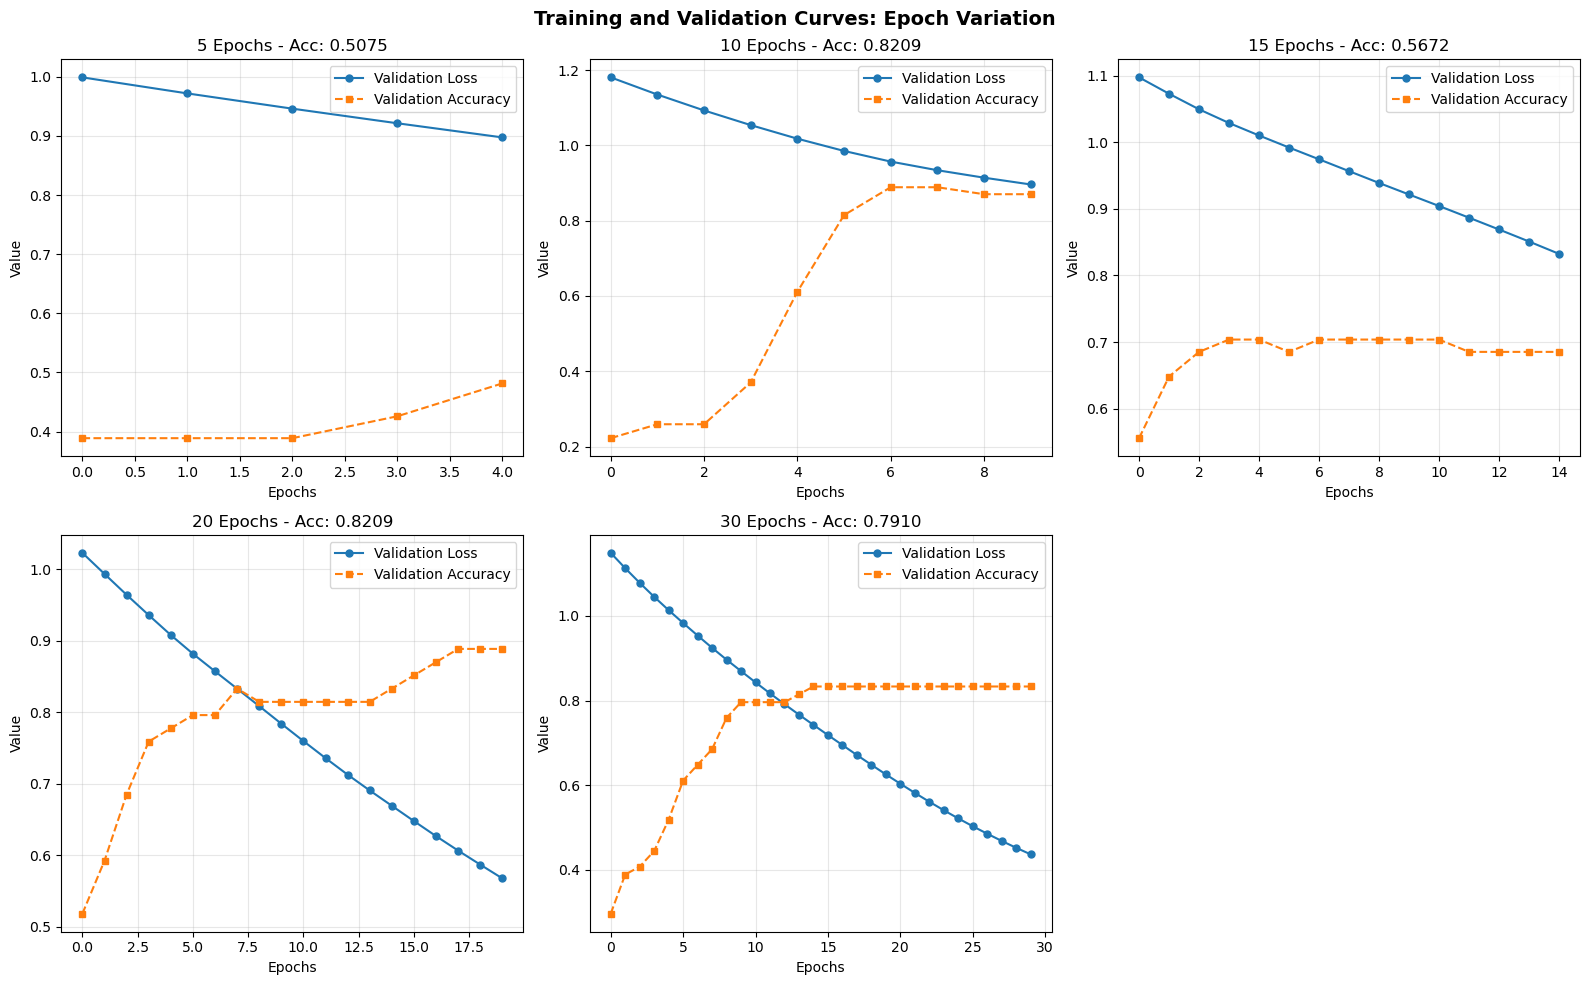

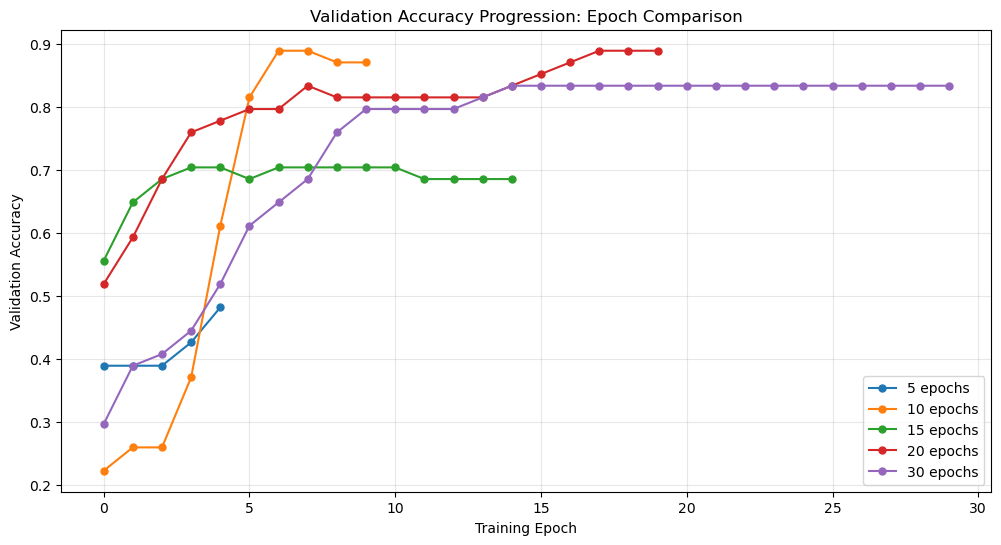


ANALYSIS: Minimum Epochs Needed for Reliable Performance

5 epochs → Val Acc: 0.4815 | Test Acc: 0.5075
   → 38.89% improvement with more epochs

10 epochs → Val Acc: 0.8704 | Test Acc: 0.8209
   ✓ Plateau reached: only -18.52% improvement with more epochs

15 epochs → Val Acc: 0.6852 | Test Acc: 0.5672
   → 20.37% improvement with more epochs

20 epochs → Val Acc: 0.8889 | Test Acc: 0.8209
   ✓ Plateau reached: only -5.56% improvement with more epochs

Minimum 10 epochs for reliable model performance


In [41]:
# Summary Table and Curve Comparison for Epochs
print("\n" + "=" * 70)
print("EPOCH COMPARISON SUMMARY")
print("=" * 70)

epochs_df = pd.DataFrame({
    'Epochs': epoch_results['epochs'],
    'Test Accuracy': epoch_results['test_accuracy'],
    'Test Loss': epoch_results['test_loss'],
    'Final Train Acc': epoch_results['final_train_acc'],
    'Final Val Acc': epoch_results['final_val_acc']
})

print("\n", epochs_df.to_string(index=False))

# Find best and minimum performing configs
best_epoch_idx = epochs_df['Test Accuracy'].idxmax()
best_epoch = epochs_df.loc[best_epoch_idx, 'Epochs']
best_test_acc = epochs_df.loc[best_epoch_idx, 'Test Accuracy']

print(f"\nBEST PERFORMANCE: {int(best_epoch)} epochs")
print(f"   Test Accuracy: {best_test_acc:.4f}")

# Create visualization comparing all epoch curves
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Training and Validation Curves: Epoch Variation', fontsize=14, fontweight='bold')

for idx, (epochs, history) in enumerate(zip(epoch_results['epochs'], epoch_results['histories'])):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    ax.plot(history.history['val_loss'], label='Validation Loss', marker='o', markersize=5)
    ax.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', markersize=5, linestyle='--')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Value')
    ax.set_title(f'{epochs} Epochs - Acc: {epoch_results["test_accuracy"][idx]:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove extra subplot if needed
axes[1, 2].remove()

plt.tight_layout()
plt.show()

# Comparison: Validation accuracy progression
plt.figure(figsize=(12, 6))

for idx, (epochs, history) in enumerate(zip(epoch_results['epochs'], epoch_results['histories'])):
    plt.plot(history.history['val_accuracy'], label=f'{epochs} epochs', marker='o', markersize=5)

plt.xlabel('Training Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Progression: Epoch Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find minimum reliable epochs
print("\n" + "=" * 70)
print("ANALYSIS: Minimum Epochs Needed for Reliable Performance")
print("=" * 70)

# Look for when validation accuracy stabilizes (< 0.5% improvement)
for idx in range(len(epoch_results['epochs'])):
    epochs = epoch_results['epochs'][idx]
    val_acc = epoch_results['final_val_acc'][idx]
    test_acc = epoch_results['test_accuracy'][idx]
    
    # Check if next epoch has significant improvement
    if idx < len(epoch_results['epochs']) - 1:
        next_val_acc = epoch_results['final_val_acc'][idx + 1]
        improvement = (next_val_acc - val_acc) * 100
        print(f"\n{epochs} epochs → Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")
        if improvement < 0.5:
            print(f"   ✓ Plateau reached: only {improvement:.2f}% improvement with more epochs")
        else:
            print(f"   → {improvement:.2f}% improvement with more epochs")

min_reliable = epoch_results['epochs'][0]
for idx in range(len(epoch_results['epochs']) - 1):
    if (epoch_results['final_val_acc'][idx + 1] - epoch_results['final_val_acc'][idx]) * 100 < 0.5:
        min_reliable = epoch_results['epochs'][idx]
        break

print(f"\nMinimum {min_reliable} epochs for reliable model performance")

### Early stopping, l2 regularization and dropout 

Doing all these for peguins is probably overkill!

In [12]:
# sample model 

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.3208 - loss: 1.3936 - val_accuracy: 0.2222 - val_loss: 1.3809
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3160 - loss: 1.3924 - val_accuracy: 0.2593 - val_loss: 1.3609
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3208 - loss: 1.3962 - val_accuracy: 0.2593 - val_loss: 1.3417
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3491 - loss: 1.3808 - val_accuracy: 0.2963 - val_loss: 1.3235
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3821 - loss: 1.3739 - val_accuracy: 0.3333 - val_loss: 1.3067
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4340 - loss: 1.3511 - val_accuracy: 0.3704 - val_loss: 1.2919
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3774 - loss: 1.3162 - val_accuracy: 0.3704 - val_loss: 1.2786
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3726 - loss: 1.3180 - val_accuracy: 0.4074 - val_loss

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [13]:
# tuning the model with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 3)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes

    inputs = keras.Input(shape=(6,))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer

    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best model weights
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=50,  # max training epochs
        validation_split=0.2,  # validation portion of training data
        verbose=0,  # suppress output during tuning
        callbacks=[early_stop]  # apply early stopping
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-14 13:05:08,770] A new study created in memory with name: no-name-cdfdd9a4-20c1-4d00-bc00-90475b434eb0
[I 2026-05-14 13:05:17,513] Trial 0 finished with value: 0.5878296494483948 and parameters: {'num_layers': 3, 'learning_rate': 0.00015082772926920028, 'batch_size': 32, 'num_units_layer_1': 10, 'num_units_layer_2': 21, 'num_units_layer_3': 28}. Best is trial 0 with value: 0.5878296494483948.
[I 2026-05-14 13:05:25,057] Trial 1 finished with value: 0.3775217831134796 and parameters: {'num_layers': 2, 'learning_rate': 0.00036608237052436965, 'batch_size': 64, 'num_units_layer_1': 21, 'num_units_layer_2': 23}. Best is trial 1 with value: 0.3775217831134796.
[I 2026-05-14 13:05:28,917] Trial 2 finished with value: 0.03577407822012901 and parameters: {'num_layers': 3, 'learning_rate': 0.009440221834113749, 'batch_size': 64, 'num_units_layer_1': 29, 'num_units_layer_2': 12, 'num_units_layer_3': 24}. Best is trial 2 with value: 0.03577407822012901.
[I 2026-05-14 13:05:37,693] Tria

Best validation loss: 0.021220270544290543
Best parameters: {'num_layers': 2, 'learning_rate': 0.0062817901405222, 'batch_size': 32, 'num_units_layer_1': 6, 'num_units_layer_2': 28}


In [14]:
# visualizing Optuna results

optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

In [15]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]  
inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)   
history = best_model.fit(X_train_scaled, y_train, batch_size=batch_size, epochs=50, validation_split=0.2, verbose=1, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)  

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.5849 - loss: 0.9711 - val_accuracy: 0.8148 - val_loss: 0.8309
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7877 - loss: 0.7799 - val_accuracy: 0.8333 - val_loss: 0.6619
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8019 - loss: 0.6116 - val_accuracy: 0.8704 - val_loss: 0.4924
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8821 - loss: 0.4436 - val_accuracy: 0.9074 - val_loss: 0.3446
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9717 - loss: 0.2910 - val_accuracy: 0.9630 - val_loss: 0.2290
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9858 - loss: 0.1726 - val_accuracy: 0.9815 - val_loss: 0.1484
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0951 - val_accuracy: 0.9815 - val_loss: 0.1005
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0537 - val_accuracy: 0.9815 - val_loss: 0.0765
